# Double distillation column: the infinite horizon vs the finite horizon

The model is the declared double column from [`models/double_column.py`](models/double_column.py):
two 41-tray columns in series separating a ternary mixture, the DAE example.
The weir flows, vapor compositions, tray temperatures, and purity aliases are
algebraic and undeclared; they ride along with the declared states. Two cases
of the same model. Case 1 runs five sampling steps with the infinite-horizon
terminal segment (`drto.infinite_horizon`,
[Dinh et al. 2025](https://doi.org/10.1016/j.jprocont.2025.103565)) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs the full twenty-five step finite horizon with the
terminal cost live.

Both cases initialize before the solve (`initialize.py`): the states
interpolate linearly from the initial condition to the steady state, and
the algebraic and cost variables then come from their defining equations
at those states. A stand-in until initialization lands in drto.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import drto
from models.double_column import double_column
from drto import plot_states, plot_controls, plot_stage_cost
from initialize import initialize_column
#import idaes
m1 = double_column(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
initialize_column(m1)
pyo.SolverFactory("pounce").solve(m1, tee=True)
#pyo.SolverFactory("ipopt").solve(m1, options={"linear_solver": "ma57"}, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmp5cwvyg1y.pyomo.nl...


Parsed 26906 vars, 26532 cons, jac_nnz=130415, h_nnz=61069 in 0.22s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:   130255
Number of nonzeros in inequality constraint Jacobian.:      160
Number of nonzeros in Lagrangian Hessian.............:    61069

Total number of variables............................:    26906
                     variables with only lower bounds:     3003
                variables with lower and upper bounds:    16272
                     variables with only upper bounds:        0
Total number of equality constraints.................:    26500
Total number of inequality constraints...............:       32
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:       32
        inequality constraints with only upper bounds:        0



iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  5.0653022e+03 5.05e+00 9.90e+01   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0


   1  2.4028473e+02 5.00e+00 9.00e+01   -1.0 2.07e+01      - 9.20e-02 1.09e-02f  1


   2  1.1704443e+03 3.83e+00 5.38e+02   -1.0 2.50e+01      - 1.49e-01 2.33e-01h  1


...

  75  2.7167492e+02 2.38e-09 3.61e-05   -8.6 2.22e-04      - 1.00e+00 1.00e+00f  1


  76  2.7167492e+02 6.17e-11 2.51e-08   -8.6 5.57e-05      - 1.00e+00 1.00e+00h  1


  77  2.7167492e+02 3.20e-12 1.25e-09   -8.6 1.29e-05      - 1.00e+00 1.00e+00h  1
pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmp5cwvyg1y.pyomo.sol




Number of Iterations....: 77

                                   (scaled)                 (unscaled)
Objective...............:   2.7167491942375353e+01    2.7167491942375352e+02
Dual infeasibility......:   1.2468037296018703e-09    1.2468037296018703e-09
Constraint violation....:   3.2025493368337266e-12    3.2025493368337266e-12
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.6107311562688732e-09    2.6107311562688732e-09
Overall NLP error.......:   2.6107311562688732e-09    2.6107311562688732e-09


Number of objective function evaluations             = 82
Number of objective gradient evaluations             = 79
Number of equality constraint evaluations            = 82
Number of inequality constraint evaluations          = 82
Number of equality constraint Jacobian evaluations   = 79
Number of inequality constraint Jacobian evaluations = 79
Number of Lagrangian Hessian evaluations             = 77
Total seconds in POUNCE    

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 26532, 'Number of variables': 26906, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 67.09396123886108}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
drto.info(m1)

horizon,"t (ContinuousSet, 16 points)"
states,"x1 (free), x2 (free), M1 (free), M2 (free)"
dynamics,"dM1[i,t] == L1[2,t] - VB1[t] - B1[t] for i in tray, t in t"
dynamics,"dx1[i,j,t] == (L1[2,t]*(x1[2,j,t] - x1[i,j,t]) - VB1[t]*(y1[i,j,t] - x1[i,j,t]))/M1[i,t] for i in tray, j in comp, t in t"
dynamics,"dM2[i,t] == L2[2,t] - VB2[t] - B2[t] for i in tray, t in t"
dynamics,"dx2[i,j,t] == (L2[2,t]*(x2[2,j,t] - x2[i,j,t]) - VB2[t]*(y2[i,j,t] - x2[i,j,t]))/M2[i,t] for i in tray, j in comp, t in t"
controls,"LT1 (piecewise_constant, free), VB1 (piecewise_constant, free), D1 (piecewise_constant, free), B1 (piecewise_constant, free), LT2 (piecewise_constant, free), VB2 (piecewise_constant, free), D2 (piecewise_constant, free), B2 (piecewise_constant, free)"
tracking stage cost,"cost[t] == (LT1[t] - LT1_ss)**2 + (VB1[t] - VB1_ss)**2 + (D1[t] - D1_ss)**2 + (B1[t] - B1_ss)**2 + (LT2[t] - LT2_ss)**2 + (VB2[t] - VB2_ss)**2 + (D2[t] - D2_ss)**2 + (B2[t] - B2_ss)**2 + 10*(SUM((x1[i,j,t] - x1_ss[i,j])**2 + (x2[i,j,t] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,t] - M1_ss[l])**2 + (M2[l,t] - M2_ss[l])**2 for l in tray)) for t in sorted(t)[:-1]"
terminal cost,"term == 10*(SUM((x1[i,j,5] - x1_ss[i,j])**2 + (x2[i,j,5] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,5] - M1_ss[l])**2 + (M2[l,5] - M2_ss[l])**2 for l in tray))"
initial conditions,"x1_hat[i,j] == x1[i,j,0] for i in tray, j in comp"
initial conditions,"x2_hat[i,j] == x2[i,j,0] for i in tray, j in comp"


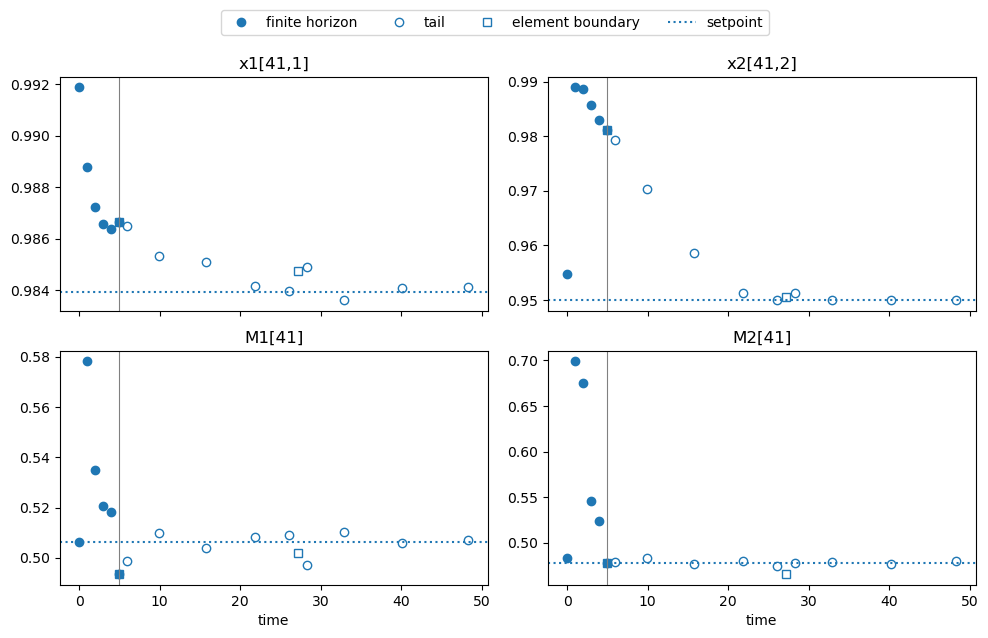

In [3]:
# multi-index states select by member: overhead purities and condenser holdups
plot_states(m1, states=["x1[41,1]", "x2[41,2]", "M1[41]", "M2[41]"]);

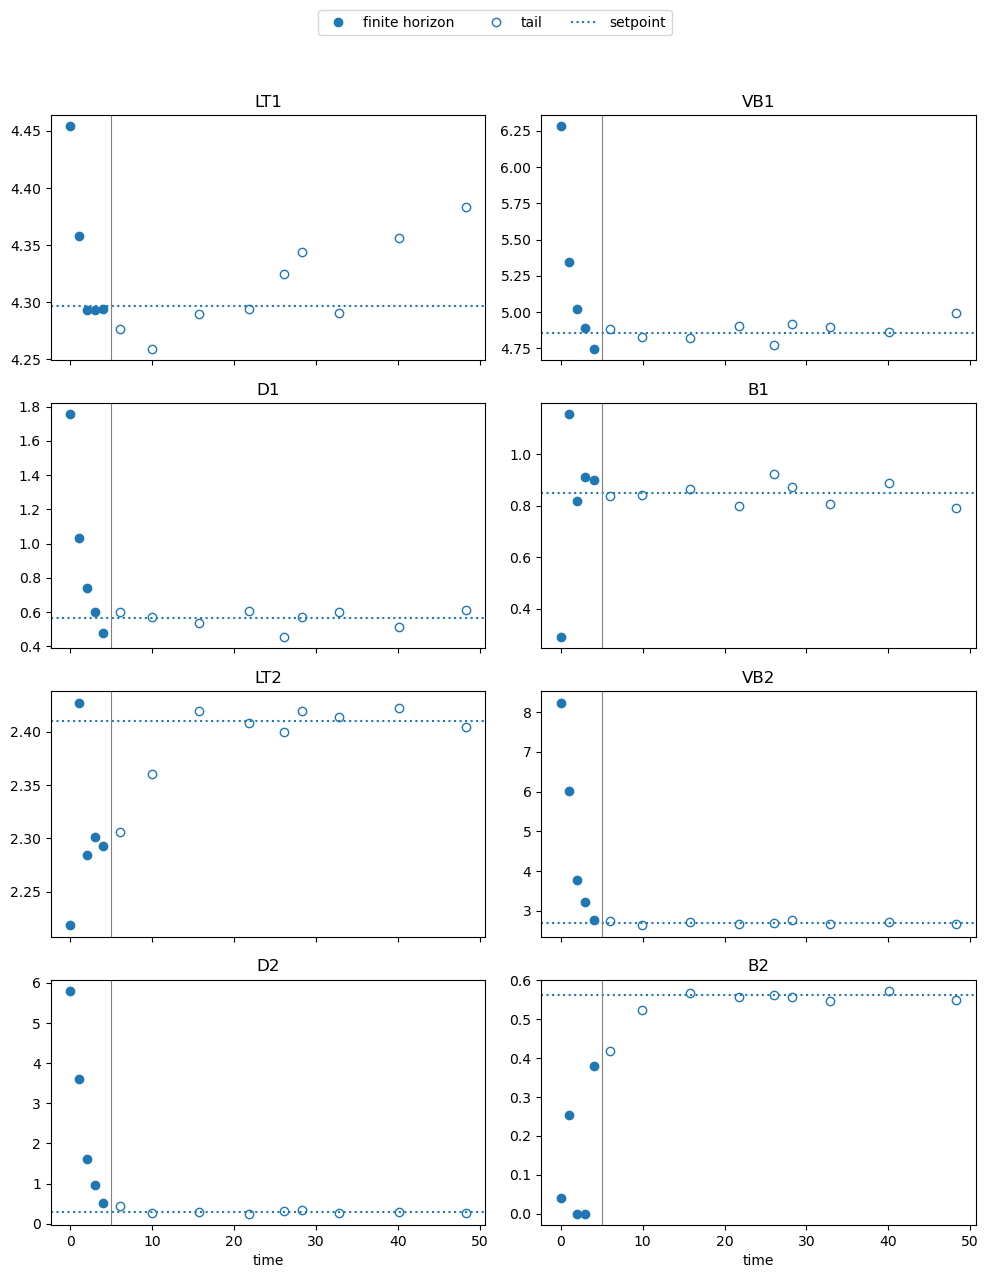

In [4]:
plot_controls(m1);

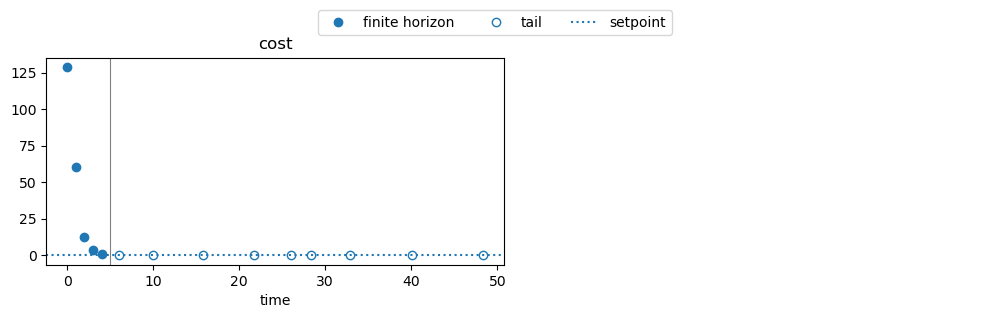

In [5]:
plot_stage_cost(m1);

## Case 2: twenty-five samples, finite horizon with the terminal cost

In [6]:
m2 = double_column(N=25)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=25, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
initialize_column(m2)
pyo.SolverFactory("pounce").solve(m2, tee=True)
#pyo.SolverFactory("ipopt").solve(m2, options={"linear_solver": "ma57"}, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpp1d03oc7.pyomo.nl...


Parsed 62166 vars, 61966 cons, jac_nnz=290486, h_nnz=145748 in 0.55s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:   290486
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:   145748

Total number of variables............................:    62166
                     variables with only lower bounds:     6156
                variables with lower and upper bounds:    37288
                     variables with only upper bounds:        0
Total number of equality constraints.................:    61966
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0



iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  5.6421478e+02 5.05e+00 1.00e+00   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0


   1  5.6320844e+02 4.75e+00 4.95e+01   -1.0 1.56e+01      - 2.23e-01 5.94e-02f  1


   2  5.6637523e+02 4.41e+00 2.49e+02   -1.0 2.05e+01      - 2.96e-01 7.17e-02f  1


...

  88  2.0881656e+02 8.12e-14 4.76e-09   -5.7 5.64e-07      - 1.00e+00 1.00e+00h  1


  89  2.0881655e+02 4.67e-08 7.98e-02   -8.6 5.57e-04      - 9.99e-01 1.00e+00h  1


iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  90  2.0881655e+02 5.68e-14 6.65e-11   -8.6 5.14e-08      - 1.00e+00 1.00e+00h  1
pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpp1d03oc7.pyomo.sol




Number of Iterations....: 90

                                   (scaled)                 (unscaled)
Objective...............:   2.0881655256813397e+02    2.0881655256813397e+02
Dual infeasibility......:   6.6523971665388368e-11    6.6523971665388368e-11
Constraint violation....:   5.6843418860808015e-14    5.6843418860808015e-14
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059041974283520e-09    2.5059041974283520e-09
Overall NLP error.......:   2.5059041974283520e-09    2.5059041974283520e-09


Number of objective function evaluations             = 104
Number of objective gradient evaluations             = 92
Number of equality constraint evaluations            = 104
Number of inequality constraint evaluations          = 104
Number of equality constraint Jacobian evaluations   = 92
Number of inequality constraint Jacobian evaluations = 92
Number of Lagrangian Hessian evaluations             = 90
Total seconds in POUNCE 

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 61966, 'Number of variables': 62166, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 280.9420461654663}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [7]:
drto.info(m2)

horizon,"t (ContinuousSet, 76 points)"
states,"x1 (free), x2 (free), M1 (free), M2 (free)"
dynamics,"dM1[i,t] == L1[2,t] - VB1[t] - B1[t] for i in tray, t in t"
dynamics,"dx1[i,j,t] == (L1[2,t]*(x1[2,j,t] - x1[i,j,t]) - VB1[t]*(y1[i,j,t] - x1[i,j,t]))/M1[i,t] for i in tray, j in comp, t in t"
dynamics,"dM2[i,t] == L2[2,t] - VB2[t] - B2[t] for i in tray, t in t"
dynamics,"dx2[i,j,t] == (L2[2,t]*(x2[2,j,t] - x2[i,j,t]) - VB2[t]*(y2[i,j,t] - x2[i,j,t]))/M2[i,t] for i in tray, j in comp, t in t"
controls,"LT1 (piecewise_constant, free), VB1 (piecewise_constant, free), D1 (piecewise_constant, free), B1 (piecewise_constant, free), LT2 (piecewise_constant, free), VB2 (piecewise_constant, free), D2 (piecewise_constant, free), B2 (piecewise_constant, free)"
tracking stage cost,"cost[t] == (LT1[t] - LT1_ss)**2 + (VB1[t] - VB1_ss)**2 + (D1[t] - D1_ss)**2 + (B1[t] - B1_ss)**2 + (LT2[t] - LT2_ss)**2 + (VB2[t] - VB2_ss)**2 + (D2[t] - D2_ss)**2 + (B2[t] - B2_ss)**2 + 10*(SUM((x1[i,j,t] - x1_ss[i,j])**2 + (x2[i,j,t] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,t] - M1_ss[l])**2 + (M2[l,t] - M2_ss[l])**2 for l in tray)) for t in sorted(t)[:-1]"
terminal cost,"term == 10*(SUM((x1[i,j,25] - x1_ss[i,j])**2 + (x2[i,j,25] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,25] - M1_ss[l])**2 + (M2[l,25] - M2_ss[l])**2 for l in tray))"
initial conditions,"x1_hat[i,j] == x1[i,j,0] for i in tray, j in comp"
initial conditions,"x2_hat[i,j] == x2[i,j,0] for i in tray, j in comp"


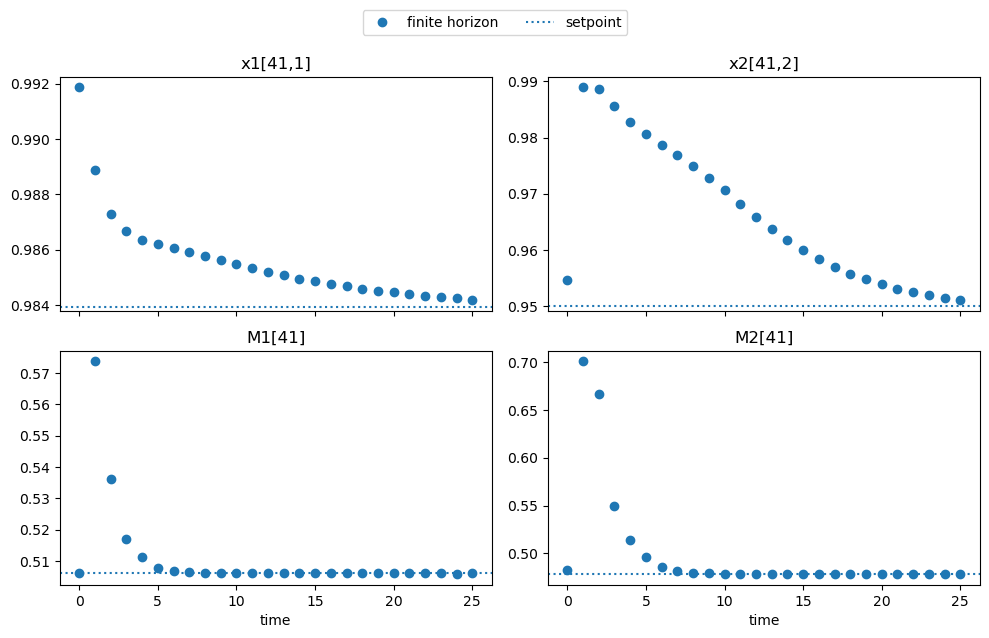

In [8]:
plot_states(m2, states=["x1[41,1]", "x2[41,2]", "M1[41]", "M2[41]"]);

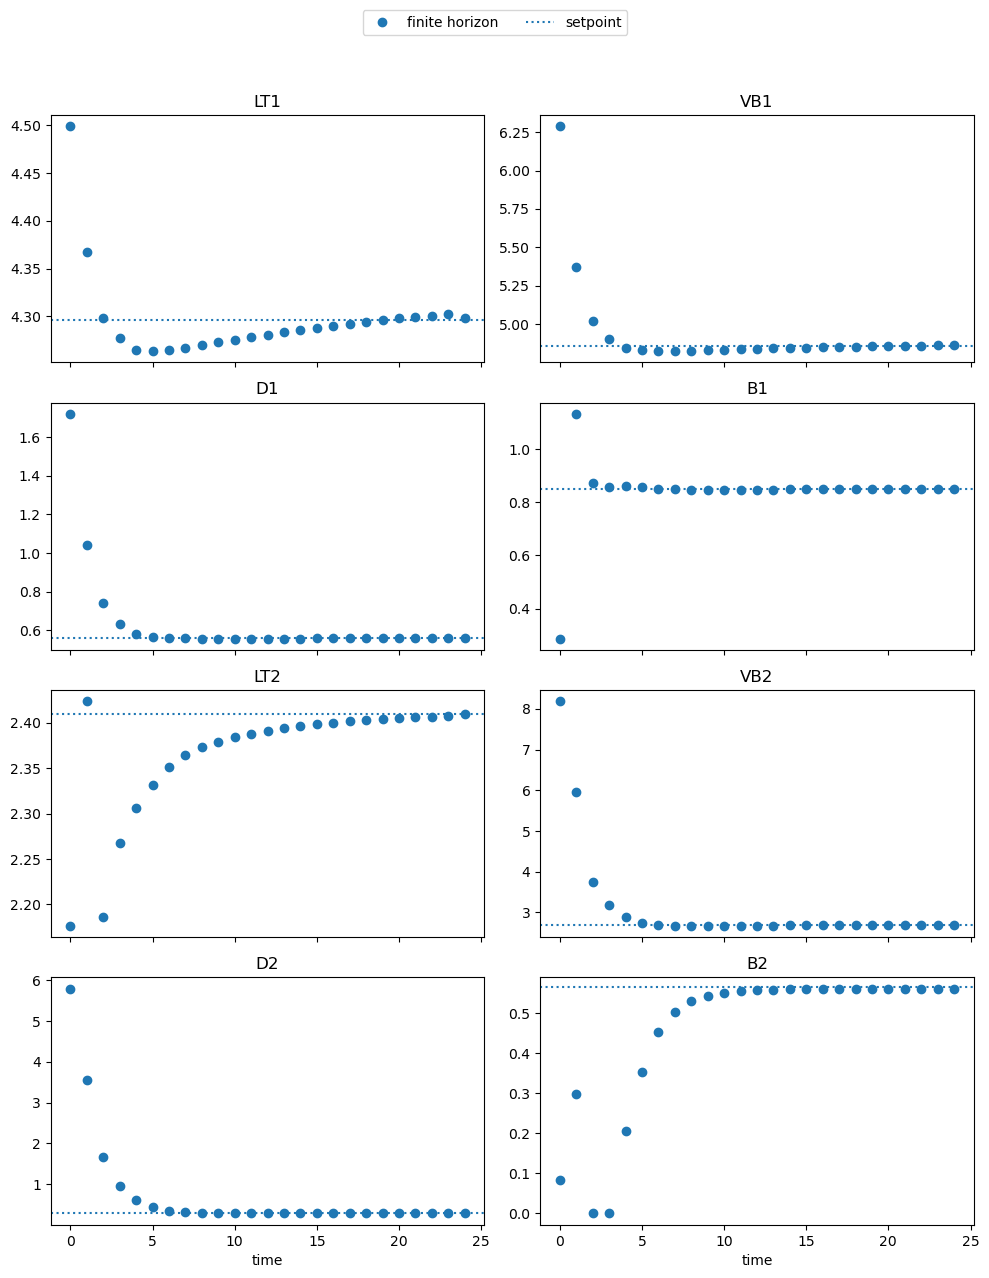

In [9]:
plot_controls(m2);

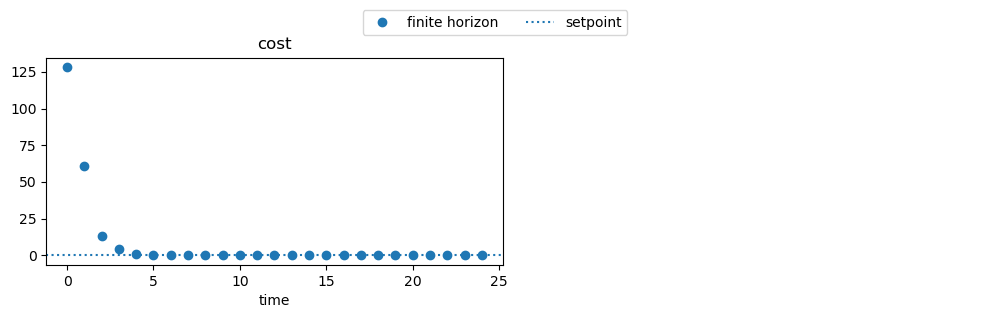

In [10]:
plot_stage_cost(m2);